# **HELE-SHAW DROPLET**

In [10]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from scipy.optimize import curve_fit
from fourier_functions import fourier_cos

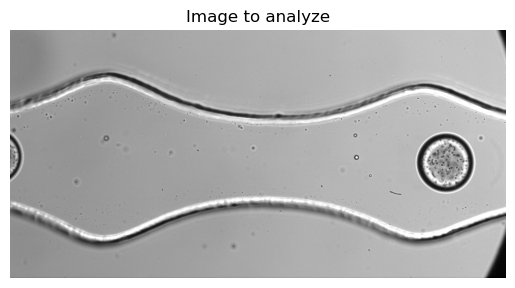

In [30]:
#HELE-SHAW droplets
#image_path = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000460.tif'
image_path = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000130.tif'
#image_path = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000760.tif'
#CELLS
#image_path = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls/0_film/cell0/cell0000002.tif'
#COACERVATES
#image_path = '/Volumes/Elements/Rheoflu/Luca/20251023_Frasatest_coacervates/1_test_CTPK240_05mM_tcGG_h60_d100/channel2_constriction5/constriction5/constriction5005635.tif'

image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/Constrict_5/Constrict_5000131.tif'
#image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls/0_film/cell0/cell0000020.tif'
#image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/20251023_Frasatest_coacervates/1_test_CTPK240_05mM_tcGG_h60_d100/channel2_constriction5/constriction5/constriction5005621.tif'

if cv2.imread(image_path) is None:
    print("Immagine non trovata. Hai collegato l'SSD?")
    sys.exit()

img = Image.open(image_path)
img1 = Image.open(image_path_firstframe)
plt.imshow(img, cmap='gray')
plt.title('Image to analyze')
plt.axis('off') # Nasconde gli assi
plt.show()

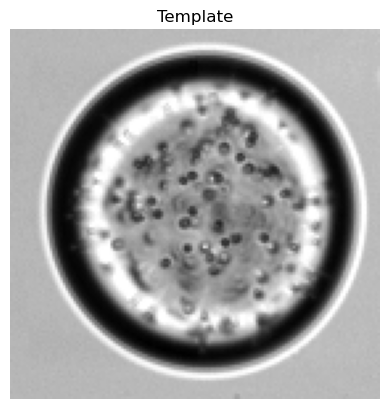

In [40]:
img = cv2.imread(image_path) #converto in array
img1 = cv2.imread(image_path_firstframe)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

y_center = 276 # --- HELE-SHAW ---
x_center = 895
radius = 70
#y_center = 194 # --- CELL ---
#x_center = 133
#radius = 20
#y_center = 53 # --- COACERVATE---
#x_center = 233
#radius = 10
template = gray_img1[y_center - radius : y_center + radius, x_center - radius : x_center + radius] #hele-shaw
h, w = template.shape # dimensioni del template

plt.imshow(template, cmap='gray')
plt.title('Template')
plt.axis('off') # Nasconde gli assi
plt.show()

# 1) **Template Matching**

Using cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED) each pixel of img receives a vote of the similarity with the template. The top left corner of the templete is taken as reference. 

Oggetto trovato con affidabilità: 0.85


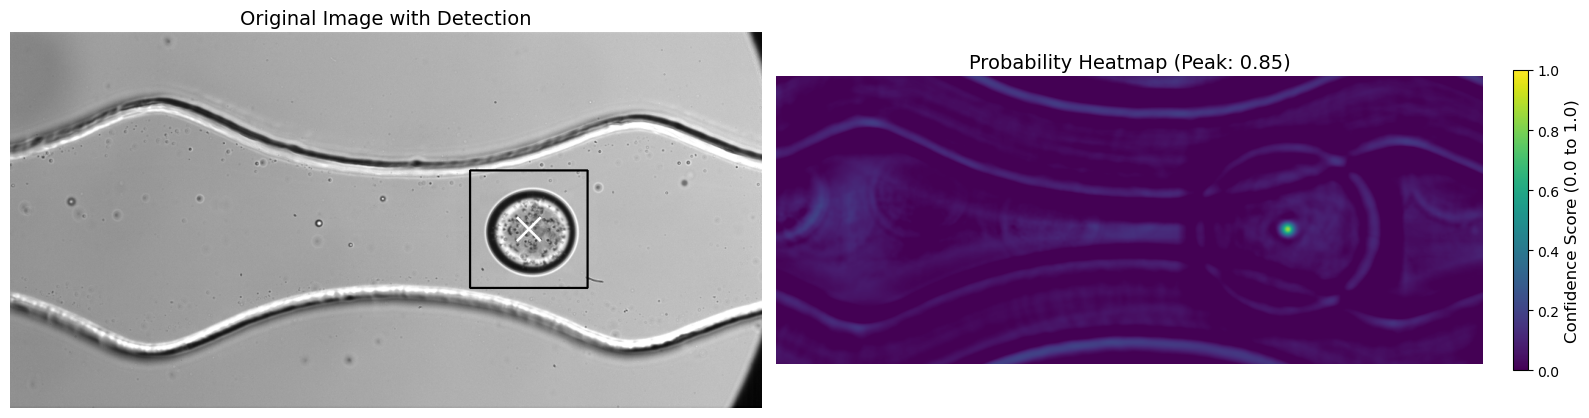

In [12]:
img = cv2.imread(image_path) #converto in array
img1 = cv2.imread(image_path_firstframe)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

y_center = 260 # --- HELE-SHAW ---
x_center = 100
radius = 80
#y_center = 194 # --- CELL ---
#x_center = 133
#radius = 20
#y_center = 53 # --- COACERVATE---
#x_center = 233
#radius = 10
template = gray_img1[y_center - radius : y_center + radius, x_center - radius : x_center + radius] #hele-shaw
h, w = template.shape # dimensioni del template

result = cv2.matchTemplate(gray, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result) #trova valori e coordinate di min e max

threshold = 0.60
if max_val >= threshold:
    top_left = max_loc      
    bottom_right = (top_left[0] + w, top_left[1] + h)
    
    ROI = gray[top_left[1]:bottom_right[1], top_left[0]:bottom_right[0]].copy() #togliere.copy se si vuole risparmiare memoria

    cv2.rectangle(gray, top_left, bottom_right, (0, 255, 0), 2) 
    print(f"Oggetto trovato con affidabilità: {max_val:.2f}")

    x_center = top_left[0] + (w//2) 
    y_center = top_left[1] + (h//2)
    cv2.drawMarker(gray, (x_center, y_center), (255, 0, 0), cv2.MARKER_TILTED_CROSS, 30, 3) 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.imshow(gray, cmap='gray')
    ax1.set_title("Original Image with Detection", fontsize=14)
    ax1.axis('off') 
    
    heatmap = ax2.imshow(result, cmap='viridis', vmin=0, vmax=1)
    ax2.set_title(f"Probability Heatmap (Peak: {max_val:.2f})", fontsize=14)
    ax2.axis('off')
    
    cbar = fig.colorbar(heatmap, ax=ax2, fraction=0.02, pad=0.04)
    cbar.set_label('Confidence Score (0.0 to 1.0)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

else:
    print("Oggetto non trovato nel frame.")

# **Edge finding**

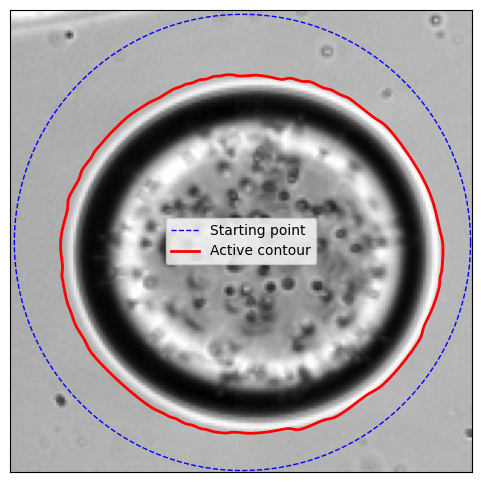

In [13]:
h_roi, w_roi = ROI.shape
radius = min(h_roi, w_roi) / 2 - 1

s = np.linspace(0, 2 * np.pi, 400) #points on a circle
y = h_roi//2 + radius * np.sin(s)  #points coordinates
x = w_roi//2 + radius * np.cos(s) 
init = np.array([y, x]).T 

ROI_blur= gaussian(ROI, sigma=1.95)  #cells=1.5,coac=1.95
contour = active_contour(ROI_blur, init, alpha=1.5, beta=10.0, w_edge=5.0, w_line=0.0, boundary_condition='periodic')


fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(ROI, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--b', lw=1, label="Starting point")
ax.plot(contour[:, 1], contour[:, 0], '-r', lw=2, label="Active contour")
ax.set_xticks([]), ax.set_yticks([]) # Nasconde i numeri sugli assi
ax.legend()
plt.show()

# **Center finding and rescaling**

We perform an initial Fourier fit that includes the sine term in the first order. We'll start with an average radius and a provisional center calculated as the center of mass. We find the true center by subtracting the coefficients of the first harmonic, a1 and b1, from the provisional coordinates.

In [20]:
#calcolo di coordinate,definizione del fit e ricerca del centro

# 2. Active Contour
Y_contour = contour[:, 0] #invertiamo le colonne di contour
X_contour = contour[:, 1]
# 3. Center of Mass
x_center_prov = np.mean(X_contour) # Troviamo il centro di massa del contour e le fissiamo come origine
y_center_prov = np.mean(Y_contour)
X_centered = X_contour - x_center_prov
Y_centered = Y_contour - y_center_prov
# 4. Polar coord
theta_contour = np.arctan2(Y_centered, X_centered) # Cartesian > Polar
radius_contour = np.sqrt(X_centered**2 + Y_centered**2)

# --- 3. FUNZIONE DI FITTING COMPLETA (Seno al 1° e Coseni) ---
def fourier_cos(theta, a0, a1, b1, a2, a3, a4): # preso un angolo, restituisce il raggio espresso come serie di coseni
    return a0 + a1*np.cos(theta) + b1*np.sin(theta) + a2*np.cos(2*theta) + a3*np.cos(3*theta) + a4*np.cos(4*theta)

# 1. Curve fit calcola tutti i parametri
initial_par = [np.mean(radius_contour)] + [0.0] * 5
fit_parameters, _ = curve_fit(fourier_cos, theta_contour, radius_contour, p0=initial_par)
# 2. Estrapolo a1 e b1 (che mi dicono di quanto è sbagliato il mio centro)
a1 = fit_parameters[1]
b1 = fit_parameters[2]
# 3. Mi sposto nel VERO centro
x_center_true = x_center_prov + a1
y_center_true = y_center_prov + b1
# 4. Ora che sono nel vero centro, ELIMINO lo shift dalla forma della goccia
fit_parameters[1] = 0.0  # azzero a1
fit_parameters[2] = 0.0  # azzero b1

# **Fourier's fit**

We perform a cosine series Fourier fit.

Average radius a0 = 64.01


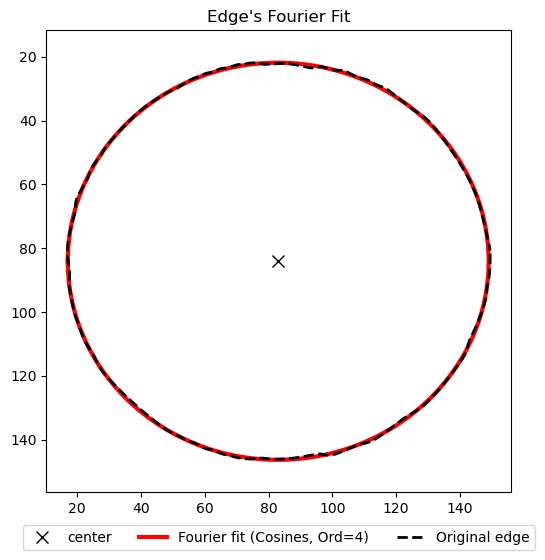

In [15]:

# 5. Genero la forma teorica. Essendo a1 e b1 zero, questa sarà una forma PURA, perfettamente centrata intorno all'origine (0,0)
theta_fit = np.linspace(-np.pi, np.pi, 400)            #disegno una curva con i parametri del fit
radius_fit = fourier_cos(theta_fit, *fit_parameters) 
# 6. E ora traccio la forma partendo dalle mie nuove coordinate centrali perfette
x_fit = x_center_true + radius_fit * np.cos(theta_fit)
y_fit = y_center_true + radius_fit * np.sin(theta_fit)
print(f"Average radius a0 = {fit_parameters[0]:.2f}")

fig, ax = plt.subplots(figsize=(6, 6))

# center calcolato
ax.plot(x_center_true, y_center_true, 'kx', markersize=8, label='center')
# Forma ideale calcolata col fitting dei coseni
ax.plot(x_fit, y_fit, '-r', lw=3, label='Fourier fit (Cosines, Ord=4)')
# contour reale trovato dall'active contour
ax.plot(X_contour, Y_contour, '--k', lw=2, label='Original edge')
ax.set_title("Edge's Fourier Fit")
ax.axis('equal') 
ax.invert_yaxis() # L'asse Y scende verso il basso nelle immagini!
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=3)

plt.show()

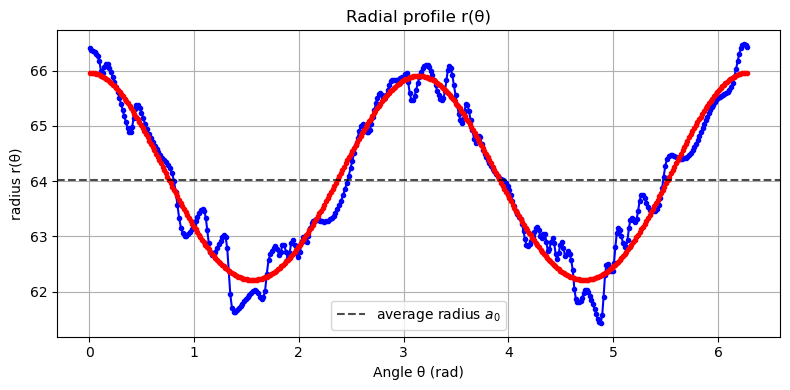

In [16]:
# Estraiamo x e y
r_contour = np.sqrt((X_contour - x_center_true)**2 + (Y_contour - y_center_true)**2) # r = √(x^2 + y^2)
r_fit = np.sqrt((x_fit - x_center_true)**2 + (y_fit - y_center_true)**2) # r = √(x^2 + y^2)


# theta = atan2(y, x), restituisce l'angolo in radianti tra -π e +π
theta_contour = np.arctan2(Y_contour - y_center_true, X_contour - x_center_true) 
theta_contour = np.mod(theta_contour, 2 * np.pi)
theta_fit = np.arctan2(y_fit - y_center_true, x_fit - x_center_true) 
theta_fit = np.mod(theta_fit, 2 * np.pi)

# 4. Ordiniamo gli array in base a theta (dal valore più piccolo al più grande)
sort_contour_indices = np.argsort(theta_contour)
theta_contour_sorted = theta_contour[sort_contour_indices]
r_contour_sorted = r_contour[sort_contour_indices]
sort_fit_indices = np.argsort(theta_fit)
theta_fit_sorted = theta_fit[sort_fit_indices]
r_fit_sorted = r_fit[sort_fit_indices]

# 5. Facciamo il plot cartesiano di r(theta)
plt.figure(figsize=(8, 4))
plt.plot(theta_contour_sorted, r_contour_sorted, color='blue', linestyle='-', marker='.')
plt.plot(theta_fit_sorted, r_fit_sorted, color='red', linestyle='-', marker='.')

plt.axhline(fit_parameters[0], color='black', linestyle='--', alpha=0.7,label='average radius $a_0$')

plt.xlabel('Angle \u03B8 (rad)')
plt.ylabel('radius r(\u03B8)')
plt.title('Radial profile r(\u03B8)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()



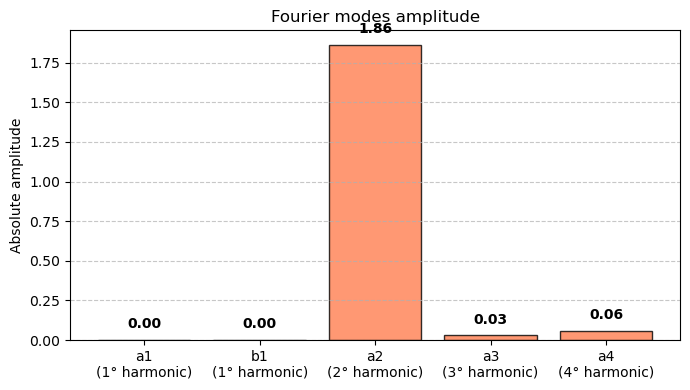

In [19]:
# Prendiamo i moduli (valori assoluti) ma SALTIAMO il primo elemento (a0) usando [1:]
harmonic_modules = np.abs(fit_parameters[1:])

# Creiamo le labels solo per le armoniche
labels = ['a1\n(1° harmonic)','b1\n(1° harmonic)', 'a2\n(2° harmonic)', 'a3\n(3° harmonic)', 'a4\n(4° harmonic)']

# Creiamo il grafico (ho cambiato colore per distinguerlo dal precedente!)
plt.figure(figsize=(7, 4))
plt.bar(labels, harmonic_modules, color='coral', edgecolor='black', alpha=0.8)

# Aggiungiamo i valori esatti sopra ogni colonna
for i, valore in enumerate(harmonic_modules):
    plt.text(i, valore + (max(harmonic_modules)*0.03), f"{valore:.2f}", 
             ha='center', va='bottom', fontweight='bold')

# Rifiniture
plt.title("Fourier modes amplitude") 
plt.ylabel("Absolute amplitude")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot of radius function r(theta)

In [18]:
#PER VIDEO

#cap = cv2.VideoCapture('percorso/cartella/frame_%04d.tif') # '%04d' indica che il numero nel nome del file ha 4 cifre (0001, 0002...)
#
#frames = []
#while True:
#    ret, frame = cap.read()
#    if not ret:
#        break 
#        
#    frames.append(frame)
#
#cap.release()